# Medium Q3 — 2022 年巴基斯坦 Indus Valley 洪水事件淹水範圍分析

## 1. 資料集選擇：Sentinel-1 SAR GRD

**為何選 Sentinel-1 SAR？**

| 項目 | 說明 |
|------|------|
| **穿透雲層** | 2022 年巴基斯坦洪水期間雲量極高（季風），光學影像幾乎無用 |
| **空間解析度** | IW（Interferometric Wide）模式：Range 5m × Azimuth 20m，最終輸出約 10m |
| **時間解析度** | 約 6–12 天重訪，洪水期間可取多景複合 |
| **使用波段** | VV 偏振（垂直發射/垂直接收），水體在 SAR 中呈低後向散射（dark），判別水體效果佳 |
| **缺點** | 水稻田、都市積水等也可能呈低後向散射，需以洪水前影像差異法來降低誤判 |

## 2. 洪水偵測方法：前後期差異法 + 閾值

1. **Before**：2022-05-01 ～ 2022-07-01（洪水前旱季）
2. **During**：2022-08-01 ～ 2022-09-30（洪水高峰期）
3. 差值 = During_VV − Before_VV（dB）；顯著降低（< −3 dB）的區域判定為淹水
4. 加入永久水體遮罩（JRC），排除河流/水庫本身

## 3. 環境設定

In [ ]:
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ee.Authenticate()
ee.Initialize(project='0')

## 4. 定義研究區域

In [2]:
# Indus Valley 中下游，2022 年主要受災範圍（Sindh 與 Balochistan 省）
indus_valley = ee.Geometry.Rectangle([66.0, 25.0, 71.0, 30.0])

SCALE_M    = 30    # 輸出解析度（保留 Sentinel-1 細節）
TARGET_CRS = 'EPSG:4326'

# 時間定義
BEFORE_START = '2022-05-01'
BEFORE_END   = '2022-07-01'
DURING_START = '2022-08-01'
DURING_END   = '2022-10-01'  # exclusive，涵蓋 9/30

print('研究區域面積 (km²):', indus_valley.area(1).divide(1e6).getInfo())

研究區域面積 (km²): 274158.1879081692


## 5. 載入 Sentinel-1 SAR GRD 並製作前後期合成影像

In [3]:
# SAR 影像篩選條件
s1_filter = [
    ee.Filter.eq('instrumentMode', 'IW'),
    ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'),
    ee.Filter.eq('orbitProperties_pass', 'DESCENDING'),  # 降軌，夜間過境，Indus 覆蓋穩定
]

# 注意：Sentinel-1 SAR 不需要雲遮罩，改用模式篩選
s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filter(ee.Filter.And(*s1_filter))
          .filterBounds(indus_valley)
          .select('VV'))

s1_before = s1_col.filterDate(BEFORE_START, BEFORE_END).mean().clip(indus_valley)
s1_during = s1_col.filterDate(DURING_START, DURING_END).mean().clip(indus_valley)

print('Before 景數:', s1_col.filterDate(BEFORE_START, BEFORE_END).size().getInfo())
print('During 景數:', s1_col.filterDate(DURING_START, DURING_END).size().getInfo())

Before 景數: 90
During 景數: 95


## 6. 洪水偵測：差異法 + 閾值

In [4]:
# 差值（dB）：洪水期間 − 洪水前，水體後向散射明顯降低 → 差值為負
vv_diff = s1_during.subtract(s1_before).rename('VV_diff')

# 驗證差值範圍
diff_stats = vv_diff.reduceRegion(
    reducer=ee.Reducer.percentile([5, 25, 50, 75, 95]),
    geometry=indus_valley,
    scale=SCALE_M,
    maxPixels=int(1e9)
)
print('VV_diff 分位數 (dB):', diff_stats.getInfo())

# 閾值設定：差值 < -3 dB 判定為新增水體
# -3 dB 為 SAR 洪水偵測文獻中的常用閾值（可調整）
FLOOD_THRESHOLD = -3
flood_raw = vv_diff.lt(FLOOD_THRESHOLD)

VV_diff 分位數 (dB): {'VV_diff_p25': -1.3737664136461964, 'VV_diff_p5': -3.870576009103509, 'VV_diff_p50': 0.374481423926886, 'VV_diff_p75': 2.3737798463576, 'VV_diff_p95': 5.622483091268235}


## 7. 排除永久水體（避免誤判河道）

In [5]:
# JRC 永久水體遮罩：occurrence >= 90% 視為永久水體
jrc = ee.Image('JRC/GSW1_4/GlobalSurfaceWater')
permanent_water = jrc.select('occurrence').gte(90)

# 洪水 = 差異法偵測到 AND 非永久水體
flood_mask = flood_raw.And(permanent_water.Not()).selfMask()

print('flood_mask bands:', flood_mask.bandNames().getInfo())

flood_mask bands: ['VV_diff']


## 8. 計算淹水面積

In [6]:
flood_area_m2 = (flood_mask.multiply(ee.Image.pixelArea())
                 .rename('area')
                 .reduceRegion(
                     reducer=ee.Reducer.sum(),
                     geometry=indus_valley,
                     scale=SCALE_M,
                     maxPixels=int(1e9)
                 ).getNumber('area'))

flood_area_km2 = flood_area_m2.divide(1e6).getInfo()
print(f'估算淹水面積: {flood_area_km2:,.1f} km²')
print(f'             ({flood_area_km2 * 100:,.0f} 公頃)')
# 官方報告：2022 年巴基斯坦洪水淹沒約 160,000 km²，供比對

估算淹水面積: 7,936.6 km²
             (793,658 公頃)


## 9. 視覺化：前後期影像 + 洪水範圍

TypeError: Invalid shape (400, 399, 2) for image data

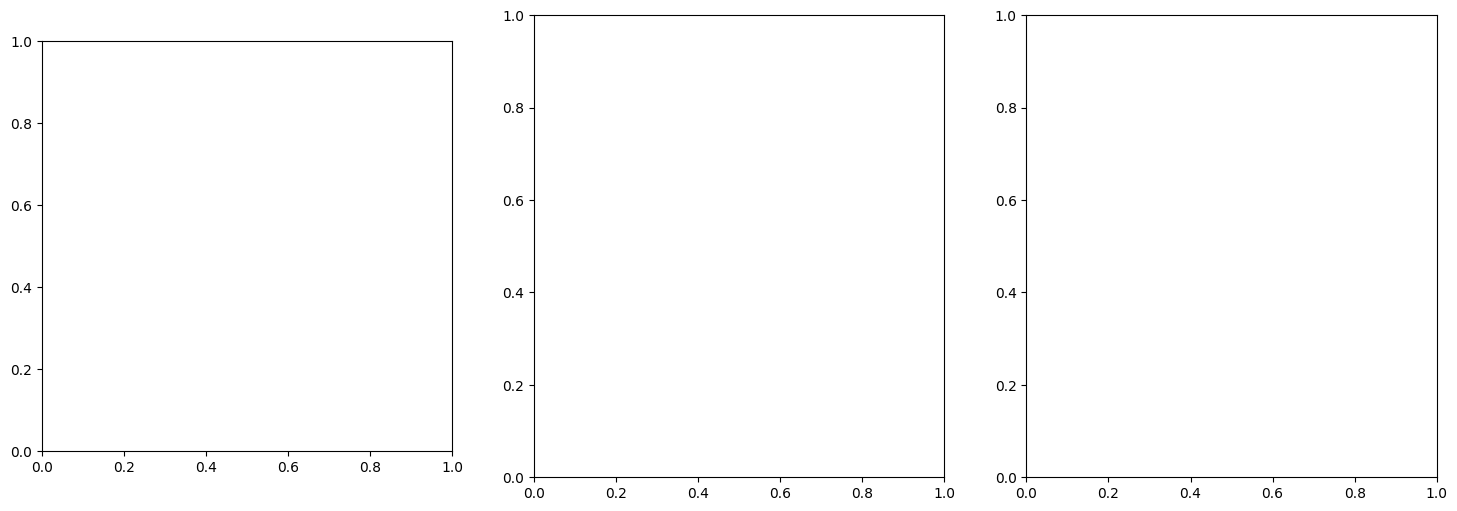

In [7]:
import requests, io
from PIL import Image as PILImage

def get_thumbnail(image, bands_or_palette, label, vmin, vmax):
    if isinstance(bands_or_palette, list) and isinstance(bands_or_palette[0], str) and bands_or_palette[0].startswith('#'):
        params = {'region': indus_valley, 'dimensions': 400,
                  'palette': bands_or_palette, 'min': vmin, 'max': vmax}
    else:
        params = {'bands': bands_or_palette, 'region': indus_valley,
                  'dimensions': 400, 'min': vmin, 'max': vmax}
    url  = image.getThumbURL(params)
    resp = requests.get(url)
    return np.array(PILImage.open(io.BytesIO(resp.content)))


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(get_thumbnail(s1_before, ['VV'], '洪水前 VV', -25, 0))
axes[0].set_title('洪水前 Sentinel-1 VV (May–Jun 2022)'); axes[0].axis('off')

axes[1].imshow(get_thumbnail(s1_during, ['VV'], '洪水中 VV', -25, 0))
axes[1].set_title('洪水中 Sentinel-1 VV (Aug–Sep 2022)'); axes[1].axis('off')

axes[2].imshow(get_thumbnail(flood_mask, ['#FFFFFF', '#1E90FF'], '淹水範圍', 0, 1))
axes[2].set_title(f'偵測淹水範圍\n(面積 ≈ {flood_area_km2:,.0f} km²)'); axes[2].axis('off')

plt.suptitle('2022 年巴基斯坦 Indus Valley 洪水分析 (Sentinel-1 SAR)', fontsize=14)
plt.tight_layout()
plt.savefig('pakistan_flood_2022.png', dpi=150)
plt.show()

## 10. 模糊地帶減少誤判的措施

以下說明如何避免將模糊地帶誤判為洪水：

1. **排除永久水體（步驟7）**：利用 JRC occurrence >= 90% 遮罩，確保河道、水庫不被計入。
2. **降軌（DESCENDING）穩定幾何**：升降軌的入射角不同，混用會引入幾何偏差，統一用降軌。
3. **時間均值（mean）合成**：取多景均值降低斑點雜訊（speckle），讓閾值更穩健。
4. **空間形態濾波**（選做）：對洪水 mask 執行形態學 opening（erosion + dilation），去除孤立像素雜訊。
5. **結合坡度遮罩**（選做）：坡度 > 5° 的山坡地在強降雨後也可能出現低後向散射（粗糙地表被平滑），可用 SRTM DEM 排除高坡度區域。

In [ ]:
# 選做：坡度遮罩（坡度 > 5° 排除）
srtm       = ee.Image('USGS/SRTMGL1_003')
terrain    = ee.Terrain.products(srtm)
slope_mask = terrain.select('slope').lt(5)

flood_refined = flood_mask.And(slope_mask).selfMask()

refined_area_km2 = (flood_refined.multiply(ee.Image.pixelArea())
                    .reduceRegion(
                        reducer=ee.Reducer.sum(),
                        geometry=indus_valley,
                        scale=SCALE_M,
                        maxPixels=int(1e9)
                    ).getNumber('area').divide(1e6).getInfo())

print(f'加入坡度遮罩後淹水面積: {refined_area_km2:,.1f} km²')
print(f'排除高坡度區域後差異:   {flood_area_km2 - refined_area_km2:,.1f} km²')

## 11. 匯出洪水範圍至 Google Drive

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=flood_refined.toFloat(),
    description='Pakistan_Flood_2022_InduValley',
    folder='GEE_Exports',
    fileNamePrefix='Pakistan_Flood_Indus_2022_S1_30m',
    region=indus_valley,
    scale=SCALE_M,
    crs=TARGET_CRS,
    maxPixels=int(1e9),
    fileFormat='GeoTIFF',
    formatOptions={'cloudOptimized': True, 'noData': 0}
)
task.start()
print('Export task started:', task.id)